# 04 — Model Explainability (SHAP)

Every risk score must be explainable — advisors cannot act on a black-box number.

- **Global:** which features matter most across all students
- **Per-student:** which features drove THIS student's score up or down
- **Output:** `data/output/predictions.csv` with top-3 SHAP features per student

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import joblib
from pathlib import Path

from src.model import compute_shap, get_tree_explainer, build_predictions_csv, top_shap_features

plt.rcParams['figure.dpi'] = 120
FIG_DIR = Path('../docs/figures')

KEY_COLS = ['code_module', 'code_presentation', 'id_student']

## Load Model and Data

In [2]:
artifact = joblib.load('../models/retention_model.pkl')
model     = artifact['model']
feat_cols = artifact['feat_cols']
print(f'Model loaded. Features: {len(feat_cols)}')

X_full = pd.read_csv('../data/processed/feature_matrix.csv')
y_full = pd.read_csv('../data/processed/labels.csv')['label']
info   = pd.read_csv('../data/raw/studentInfo.csv',
                     usecols=['code_module', 'code_presentation', 'id_student',
                              'gender', 'age_band', 'imd_band', 'final_result'])

X = X_full[feat_cols]
print(f'Scoring {len(X):,} student-module pairs')

Model loaded. Features: 39
Scoring 32,593 student-module pairs


## Compute SHAP Values

In [3]:
print('Computing SHAP values for all 32,593 rows...')
shap_values = compute_shap(model, X)
explainer   = get_tree_explainer(model)

print(f'SHAP array shape: {shap_values.shape}')  # (32593, 39)
print(f'Mean |SHAP| per feature (top 10):')
mean_abs = pd.Series(np.abs(shap_values).mean(axis=0), index=feat_cols)
print(mean_abs.sort_values(ascending=False).head(10).round(4).to_string())

Computing SHAP values for all 32,593 rows...


SHAP array shape: (32593, 39)
Mean |SHAP| per feature (top 10):
days_since_last_vle      0.6683
submission_count_w6      0.4230
studied_credits          0.2930
avg_score_w6             0.2027
early_submission_days    0.1777
edu_num                  0.1722
vle_rolling_w6           0.1502
active_days_w6           0.1501
submission_rate_w4       0.1230
age_band_num             0.1175


## Global Feature Importance (SHAP Summary Plot)

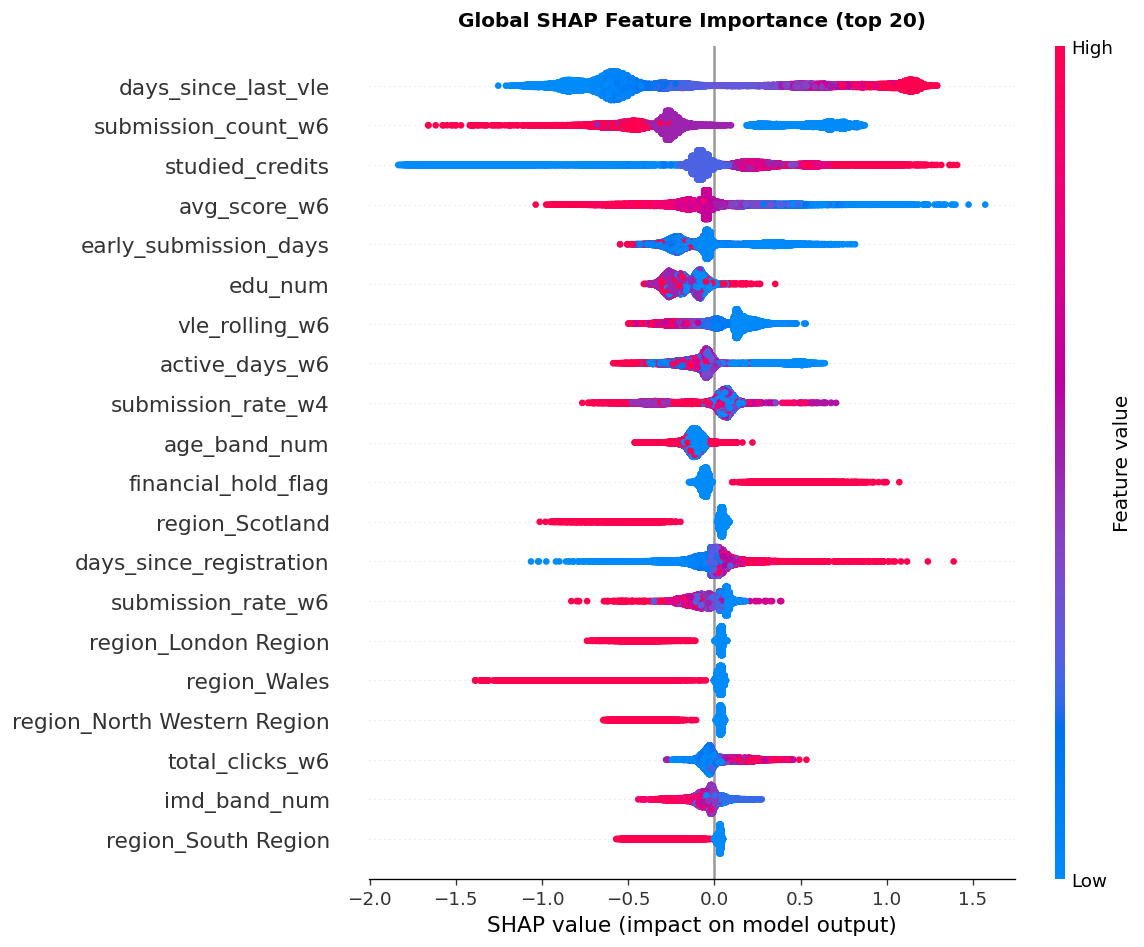

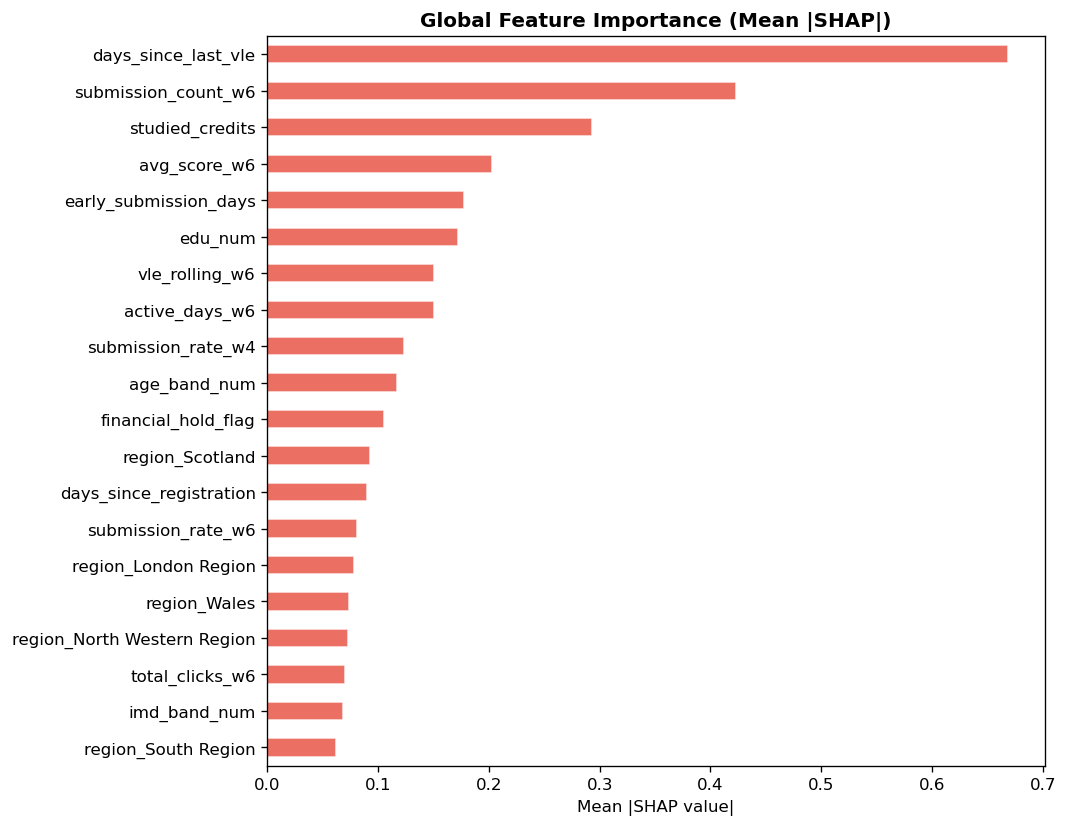

In [4]:
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(
    shap_values, X,
    feature_names=feat_cols,
    max_display=20,
    show=False,
    plot_size=None,
)
plt.title('Global SHAP Feature Importance (top 20)', fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(FIG_DIR / 'shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# Bar chart version (cleaner for dashboard)
top20 = mean_abs.sort_values(ascending=False).head(20)
fig, ax = plt.subplots(figsize=(9, 7))
top20.sort_values().plot(kind='barh', ax=ax, color='#e74c3c', alpha=0.8, edgecolor='white')
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Global Feature Importance (Mean |SHAP|)', fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'shap_importance_bar.png', dpi=150, bbox_inches='tight')
plt.show()

## Per-Student Waterfall Charts

Sample one high-risk withdrawn student and one low-risk retained student.

In [5]:
proba = model.predict_proba(X)[:, 1]
risk_scores = proba * 100

# High-risk withdrawn: model correctly flags
withdrawn_mask = y_full.values == 1
high_risk_idx = np.where(withdrawn_mask & (risk_scores > 70))[0]
sample_high = high_risk_idx[0] if len(high_risk_idx) > 0 else withdrawn_mask.nonzero()[0][0]

# Low-risk retained: model correctly clears
retained_mask = y_full.values == 0
low_risk_idx = np.where(retained_mask & (risk_scores < 30))[0]
sample_low = low_risk_idx[0] if len(low_risk_idx) > 0 else retained_mask.nonzero()[0][0]

print(f'High-risk example (idx={sample_high}): risk={risk_scores[sample_high]:.1f}, true_label={y_full.iloc[sample_high]}')
print(f'Low-risk example  (idx={sample_low}):  risk={risk_scores[sample_low]:.1f}, true_label={y_full.iloc[sample_low]}')

High-risk example (idx=2): risk=86.0, true_label=1
Low-risk example  (idx=0):  risk=12.5, true_label=0


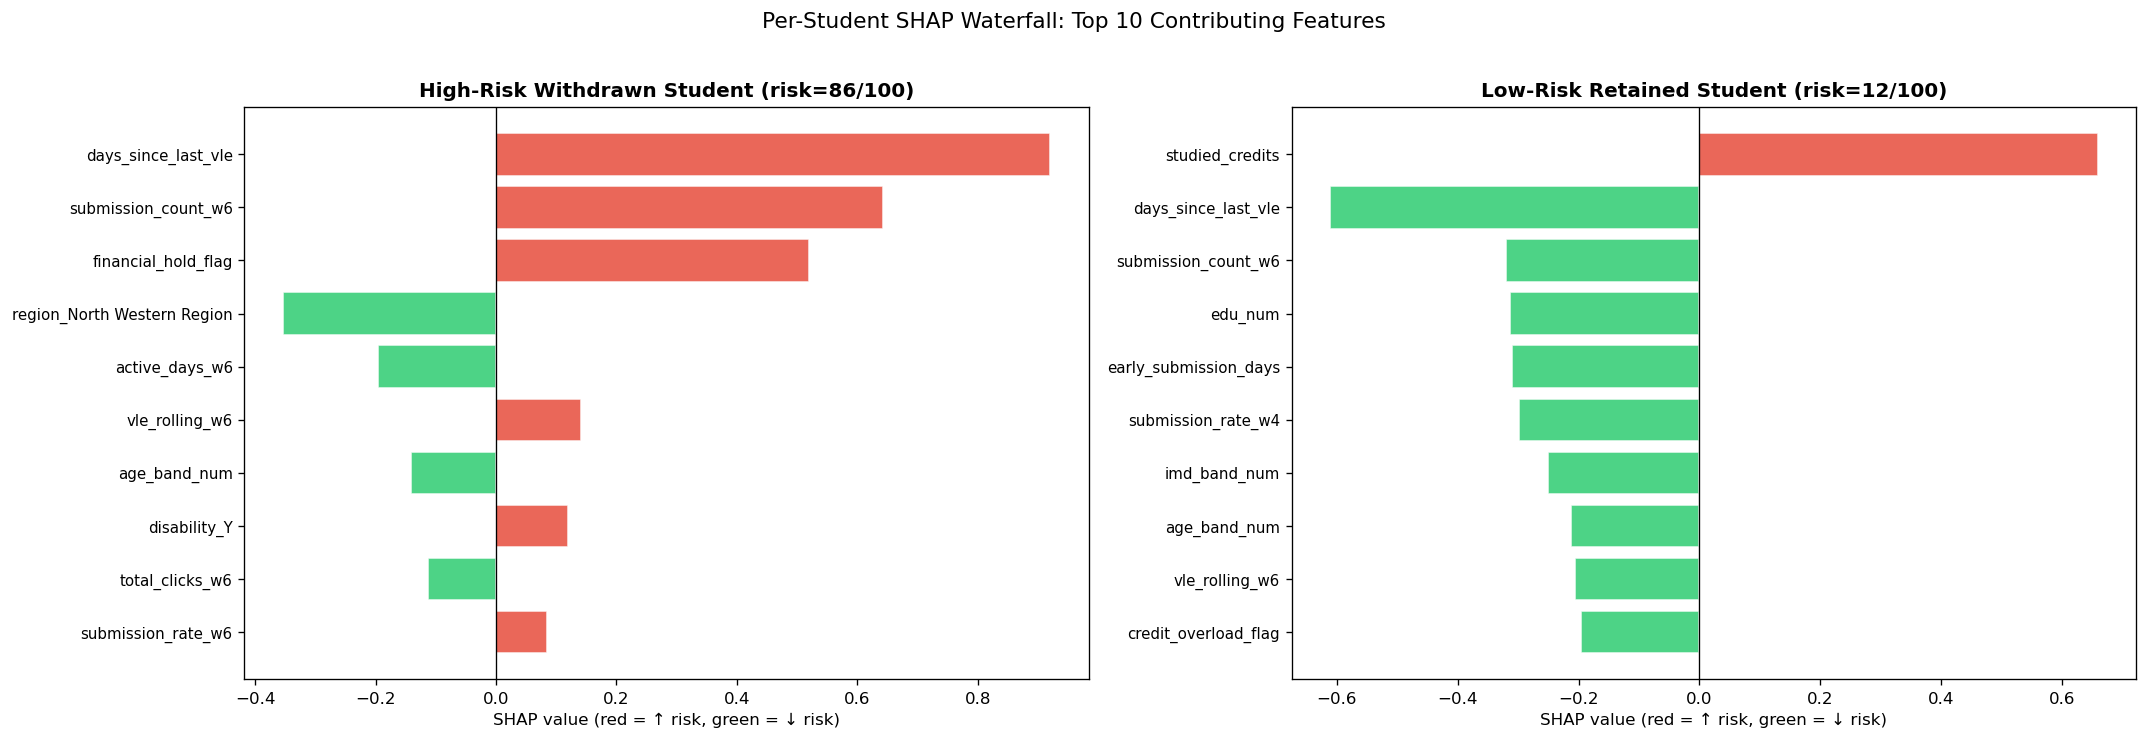

In [6]:
expected_value = explainer.expected_value
if isinstance(expected_value, (list, np.ndarray)):
    expected_value = expected_value[0]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, idx, title_suffix in [
    (axes[0], sample_high, f'High-Risk Withdrawn Student (risk={risk_scores[sample_high]:.0f}/100)'),
    (axes[1], sample_low,  f'Low-Risk Retained Student (risk={risk_scores[sample_low]:.0f}/100)'),
]:
    sv_row = shap_values[idx]
    top_n = 10
    order = np.argsort(np.abs(sv_row))[::-1][:top_n]
    top_feats = [feat_cols[i] for i in order]
    top_vals  = sv_row[order]

    colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in top_vals]
    y_pos = np.arange(top_n)
    ax.barh(y_pos, top_vals[::-1], color=colors[::-1], edgecolor='white', alpha=0.85)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(top_feats[::-1], fontsize=9)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('SHAP value (red = ↑ risk, green = ↓ risk)')
    ax.set_title(title_suffix, fontweight='bold')

plt.suptitle('Per-Student SHAP Waterfall: Top 10 Contributing Features', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'shap_waterfall_examples.png', dpi=150, bbox_inches='tight')
plt.show()

## Generate predictions.csv

In [7]:
preds = build_predictions_csv(
    model=model,
    X_full=X_full,
    y_full=y_full,
    info=info,
    save_path='../data/output/predictions.csv',
)

print()
print('Sample predictions (highest risk scores):')
display(preds.nlargest(10, 'risk_score')[[
    'id_student', 'code_module', 'risk_score', 'predicted_label', 'true_label',
    'top_shap_feature_1', 'top_shap_value_1', 'top_shap_feature_2', 'top_shap_value_2'
]])

Computing SHAP values (this may take ~30s)...


Saved 32,593 predictions to ..\data\output\predictions.csv

Sample predictions (highest risk scores):


,id_student,code_module,risk_score,predicted_label,true_label,top_shap_feature_1,top_shap_value_1,top_shap_feature_2,top_shap_value_2
9498,572909,CCC,92.5,1,1,days_since_last_vle,1.2327,days_since_registration,0.9786
13446,423474,DDD,92.5,1,1,days_since_last_vle,1.2219,days_since_registration,0.8324
22550,355149,FFF,92.5,1,1,days_since_last_vle,1.1924,days_since_registration,0.8969
4888,320661,BBB,92.4,1,1,days_since_last_vle,1.1628,studied_credits,0.8548
6468,254313,BBB,92.4,1,1,days_since_last_vle,1.2468,studied_credits,1.0807
6681,496373,BBB,92.4,1,1,studied_credits,1.3869,days_since_last_vle,1.2167
7595,652744,BBB,92.4,1,1,days_since_last_vle,1.1911,studied_credits,0.9682
10370,1407549,CCC,92.4,1,1,days_since_last_vle,1.2320,submission_count_w6,0.8301
10589,2691780,CCC,92.4,1,1,days_since_last_vle,1.2157,submission_count_w6,0.8403
12138,639176,CCC,92.4,1,1,studied_credits,1.3666,days_since_last_vle,1.1823
